# Stim/belief projection simulation

Power check for the B-split projection result (pref on the stim axis, at chance): if the stim axis
(A vs. B) and the belief axis (B vs. C) were aligned with cosine cos(theta), would the pipeline show
it, given the real runs' sessions, units and trial counts? See
`claude_notes/Stim Belief projection simulation proposal.md`.

Computed by `scripts/pseudo_decoding/belief_partitions/stim_belief_projection_sim.py`, launched by
`slurm_launch_stim_belief_projection_sim.sh`, on the layout and targets from
`stim_belief_sim_layout.py`.

1. **Calibration**: the stim signal s from the stim gap (true - shuffle) over its peak window, and
   the pref signal p from the all-bin pref gap, analytically, into `calibration.json`.
2. **Simulation**: projection gap and power against cos(theta), per population, B split vs. no split.

Everything is one time bin, so each simulated test is comparable to the real **per-bin** test, not to
the real all-bin averages, which are much less noisy.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import glob
import json
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

import utils.stats_utils as stats_utils
import utils.visualization_utils as visualization_utils
from constants.decoding_constants import *
from scripts.pseudo_decoding.belief_partitions.stim_belief_sim_layout import LAYOUT_PATH, OUTPUT_PATH, POPULATIONS
from scripts.pseudo_decoding.belief_partitions.stim_belief_projection_sim import CALIBRATION_PATH

plt.rcParams.update({"font.size": 14})

NAMES = {"whole_pop": "whole population", **{r: visualization_utils.REGION_TO_ABBREV[r] for r in REGIONS_OF_INTEREST}}
ALPHA = 0.05

targets = pd.read_pickle(LAYOUT_PATH)["targets"].set_index("population")
targets.drop(columns="stim_window").round(3)

,stim_window_fallback,stim_gap_peak,stim_gap_all,pref_gap_all,proj_gap_all_b_split,proj_gap_peak_b_split,proj_gap_all_no_split,proj_gap_peak_no_split
population,,,,,,,,
whole_pop,False,0.053,0.045,0.112,-0.003,0.002,0.004,0.006
amygdala_Amy,False,0.039,0.029,0.037,-0.004,-0.007,-0.017,-0.016
basal_ganglia_BG,False,0.039,0.018,0.027,-0.006,-0.003,-0.011,-0.009
inferior_temporal_cortex_ITC,False,0.065,0.055,0.061,-0.003,-0.001,-0.004,-0.000
medial_pallium_MPal,False,0.051,0.012,0.050,-0.001,0.007,-0.009,-0.011
lateral_prefrontal_cortex_lat_PFC,False,0.046,0.029,0.061,-0.017,-0.019,-0.009,-0.007
anterior_cingulate_gyrus_ACgG,False,0.046,0.005,0.043,0.008,0.008,-0.006,-0.010


## Calibration

Analytic, from `stim_belief_projection_sim.py --mode calibrate` (see its docstring). A decoder whose
weights are the true mean difference plus the noise of estimating it has expected accuracy
Phi(d^2 / (2 sqrt(d^2 + kappa T))), T = sum over units of (1/n_0,train + 1/n_1,train). s is solved from
the stim gap over its peak window, p (the norm of v_pref, which lives on the pref units only) from
the all-bin pref gap. kappa is the trained decoder's shortfall against a plain mean difference, fit
once: 1.2 for stim, 1.65 for pref.

`rho_expected` is the expected cosine between the estimated and true stim axes, and
`proj_acc_ceiling` the projection's accuracy along that axis at cos(theta) = 1: a rough ceiling
before any simulation.

In [2]:
calibration = pd.DataFrame(json.load(open(CALIBRATION_PATH))).T.rename(index=NAMES)
calibration.round(3)

,s,p,stim_noise_factor,pref_noise_factor,stim_gap_target,pref_gap_target,T_stim,T_pref,rho_expected,proj_acc_ceiling
whole population,1.404,1.704,1.2,1.65,0.053,0.112,54.275,23.614,0.230,0.578
AMY,0.634,0.505,1.2,1.65,0.039,0.037,3.896,1.713,0.370,0.537
DSTR,0.630,0.416,1.2,1.65,0.039,0.027,3.967,1.539,0.365,0.530
ITC,1.013,0.801,1.2,1.65,0.065,0.061,9.188,4.024,0.383,0.561
HC,0.781,0.617,1.2,1.65,0.051,0.050,5.491,2.289,0.384,0.547
LPFC,0.845,0.802,1.2,1.65,0.046,0.061,9.288,4.146,0.324,0.552
ACC,0.655,0.523,1.2,1.65,0.046,0.043,3.212,1.385,0.412,0.543


Once the simulation has run: do the simulated gaps land on their targets? Stim has no shuffle in the
simulation, so its gap is taken against 0.5, which the simulated null sits at. Pref doesn't depend on
cos(theta), so its gap is averaged over it. `sem` is over features and repeats.

In [3]:
def calibration_check(accs):
    b = accs[accs.split == "b_split"]
    per = b.assign(kind=b.shuffle_type).groupby(["population", "analysis", "kind", "feat", "repeat"]).Accuracy.mean()
    rows = []
    for population in POPULATIONS:
        stim = per[(population, "choice", "true")]
        pref_true, pref_shuffle = per[(population, "pref", "true")], per[(population, "pref", "shuffle")]
        cal = json.load(open(CALIBRATION_PATH))[population]
        rows.append({
            "population": NAMES[population],
            "stim gap": stim.mean() - 0.5, "stim sem": stim.sem(), "stim target": cal["stim_gap_target"],
            "pref gap": pref_true.mean() - pref_shuffle.mean(), "pref sem": pref_true.sem(), "pref target": cal["pref_gap_target"],
        })
    return pd.DataFrame(rows).set_index("population")

## Simulation

Per (population, split, cos(theta), repeat), over its 12 features:

- proj gap and pref gap, true - shuffle, and frac = proj gap / pref gap, as in the paper's summary
- p, the paper's per-bin test, `stats_utils.compute_p_per_group` on the true (feature x split) values
  against the shuffle ones

Power is the fraction of repeats with p < ALPHA.

In [4]:
def read_simulation():
    files = [f for f in glob.glob(os.path.join(OUTPUT_PATH, "simulate", "*", "*.pickle")) if "_smoke" not in f]
    outs = [pd.read_pickle(f) for f in files]
    accs = pd.concat([o["accs"] for o in outs], ignore_index=True)
    extras = pd.concat([o["extras"] for o in outs], ignore_index=True)
    accs["shuffle_type"] = np.where(accs.shuffle_idx.isna(), "true", "shuffle")
    return accs, extras


def summarize(accs):
    rows = []
    keys = ["population", "split", "cos_theta", "repeat"]
    for key, group in accs[accs.analysis != "choice"].groupby(keys):
        row = dict(zip(keys, key))
        for analysis in ["pref", "proj"]:
            sub = group[group.analysis == analysis]
            means = sub.groupby("shuffle_type").Accuracy.mean()
            row[f"{analysis}_true"] = means["true"]
            row[f"{analysis}_gap"] = means["true"] - means["shuffle"]
            row[f"{analysis}_p"] = stats_utils.compute_p_per_group(sub, "Accuracy", "shuffle_type")
        row["frac"] = row["proj_gap"] / row["pref_gap"]
        rows.append(row)
    return pd.DataFrame(rows)


accs, extras = read_simulation()
print(accs.groupby(["population", "split"])[["feat", "repeat"]].nunique())
summary = summarize(accs)
extras_mean = extras.groupby(["population", "split", "cos_theta"]).mean(numeric_only=True).reset_index()
calibration_check(accs).round(3)

                                            feat  repeat
population                        split                 
amygdala_Amy                      b_split     12       5
                                  no_split    12       5
anterior_cingulate_gyrus_ACgG     b_split     12       5
                                  no_split    12       5
basal_ganglia_BG                  b_split     12       5
                                  no_split    12       5
inferior_temporal_cortex_ITC      b_split     12       5
                                  no_split    12       5
lateral_prefrontal_cortex_lat_PFC b_split     12       5
                                  no_split    12       5
medial_pallium_MPal               b_split     12       5
                                  no_split    12       5
whole_pop                         b_split     12       5
                                  no_split    12       5


,stim gap,stim sem,stim target,pref gap,pref sem,pref target
population,,,,,,
whole population,0.048,0.008,0.053,0.122,0.009,0.112
AMY,0.046,0.012,0.039,0.045,0.009,0.037
DSTR,0.045,0.010,0.039,0.039,0.012,0.027
ITC,0.066,0.012,0.065,0.053,0.009,0.061
HC,0.041,0.012,0.051,0.075,0.011,0.050
LPFC,0.041,0.010,0.046,0.072,0.009,0.061
ACC,0.053,0.009,0.046,0.062,0.008,0.043


### Projection gap vs. cos(theta)

Mean ± sd over repeats (each repeat is one set of 12 features). Dotted: the observed proj gap for the
matching split variant, in the stim peak window. Dashed: the isotropic prediction along the estimated
axis, `pred_proj_acc - 0.5`, averaged over features and repeats. It floors at chance, because the
refit threshold with a fixed sign can't go below 0.5, so anti-alignment reads the same as none.

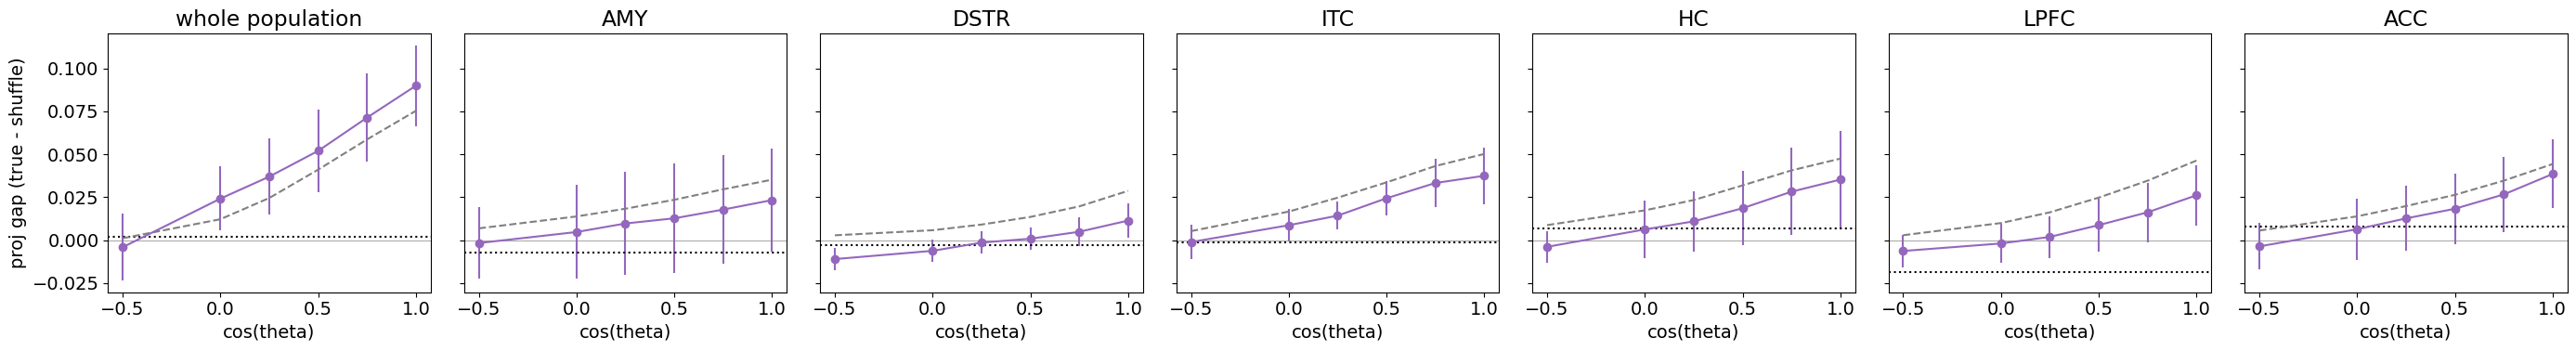

In [5]:
def plot_by_population(y, ylabel, observed_col=None, pred_col=None, split="b_split", hline=0):
    fig, axs = plt.subplots(1, len(POPULATIONS), figsize=(4 * len(POPULATIONS), 4), sharey=True)
    for ax, population in zip(axs, POPULATIONS):
        sub = summary[(summary.population == population) & (summary.split == split)]
        stats = sub.groupby("cos_theta")[y].agg(["mean", "std"])
        ax.errorbar(stats.index, stats["mean"], yerr=stats["std"].fillna(0), marker="o", color="tab:purple")
        if observed_col is not None:
            ax.axhline(targets.loc[population, observed_col], color="black", linestyle="dotted")
        if pred_col is not None:
            pred = extras_mean[(extras_mean.population == population) & (extras_mean.split == split)]
            ax.plot(pred.cos_theta, pred[pred_col] - 0.5, color="grey", linestyle="dashed")
        if hline is not None:
            ax.axhline(hline, color="grey", linewidth=0.5)
        ax.set_title(NAMES[population])
        ax.set_xlabel("cos(theta)")
    axs[0].set_ylabel(ylabel)
    fig.tight_layout()
    return fig


plot_by_population("proj_gap", "proj gap (true - shuffle)", observed_col="proj_gap_peak_b_split", pred_col="pred_proj_acc");

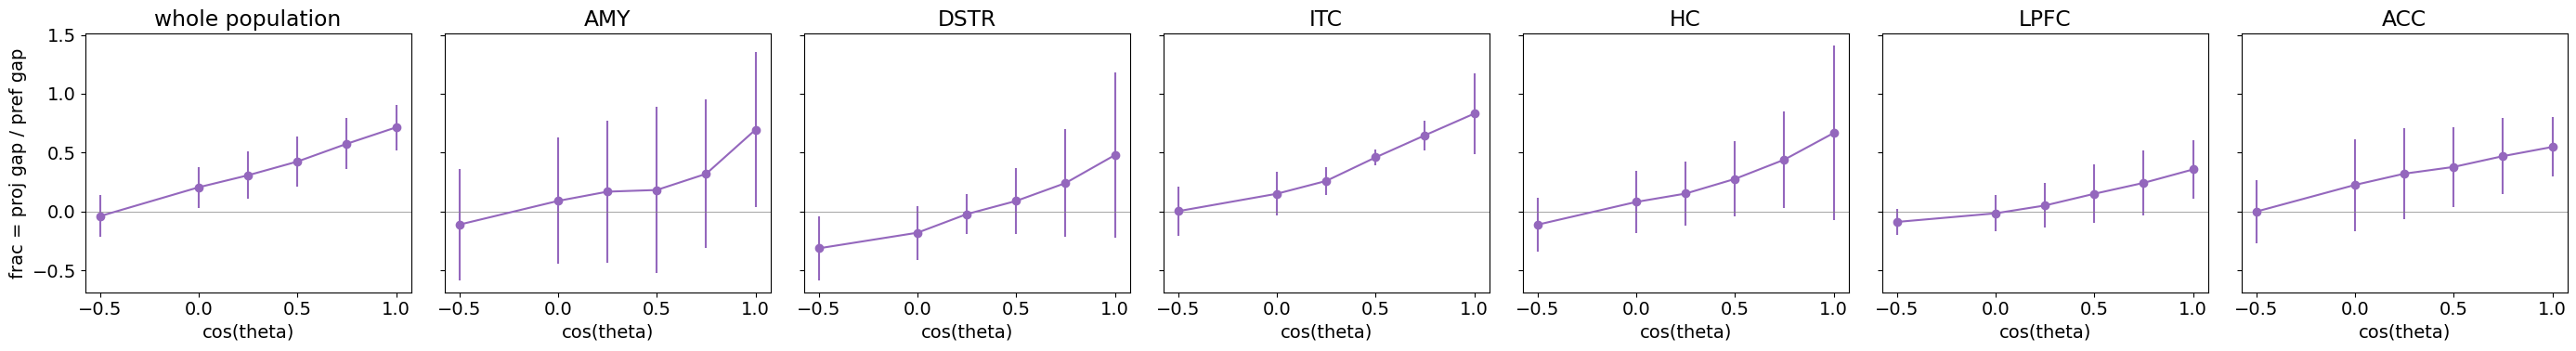

In [6]:
plot_by_population("frac", "frac = proj gap / pref gap");

### Power vs. cos(theta)

The smallest detectable cos(theta) per population is the lowest one reaching 80% power. With only
~5 repeats this is coarse, so read it as a range.

population
whole population    0.25
AMY                  NaN
DSTR                 NaN
ITC                 0.50
HC                   NaN
LPFC                1.00
ACC                 0.50
Name: cos_theta, dtype: float64

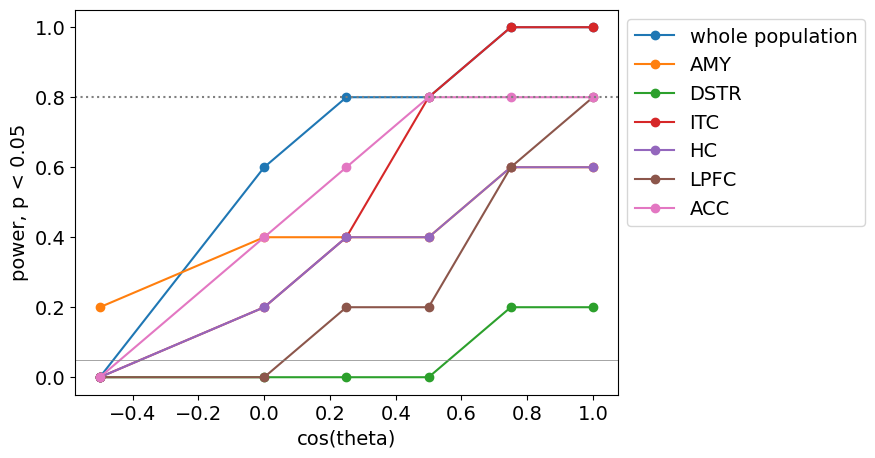

In [7]:
power = summary.assign(sig=summary.proj_p < ALPHA).groupby(["population", "split", "cos_theta"]).sig.mean().reset_index(name="power")

fig, ax = plt.subplots(figsize=(7, 5))
for i, population in enumerate(POPULATIONS):
    sub = power[(power.population == population) & (power.split == "b_split")]
    ax.plot(sub.cos_theta, sub.power, marker="o", color=f"C{i}", label=NAMES[population])
ax.axhline(0.8, color="grey", linestyle="dotted")
ax.axhline(ALPHA, color="grey", linewidth=0.5)
ax.set_xlabel("cos(theta)")
ax.set_ylabel(f"power, p < {ALPHA}")
ax.legend(bbox_to_anchor=(1, 1), loc="upper left")

min_detectable = power[(power.split == "b_split") & (power.power >= 0.8)].groupby("population").cos_theta.min() \
    .reindex(POPULATIONS).rename(index=NAMES)
min_detectable

### B split vs. no split at cos(theta) = 0

The Issue 2 check: without the split, a B trial's own noise helps build the axis and pushes it toward
C, so no_split should sit *below* b_split. Also where the observed regional values fall in the
simulated cos(theta) = 0 distribution.

Expect the b_split null to sit a little *above* 0. The estimated axis's noise overlaps the pref
direction by chance, positively for some features and negatively for others. The fixed-sign
threshold refit floors the negative ones at 0.5 but keeps the positive ones, so the mean over
features lands above chance. The shuffle removes the pref difference, so it doesn't reproduce this.
This is a bias of the real analysis too, and grows with pref signal and axis noise: about +0.02 to
+0.05 for the whole population in the checks.

mean    std
population                        split                 
amygdala_Amy                      b_split   0.005  0.027
                                  no_split -0.009  0.010
anterior_cingulate_gyrus_ACgG     b_split   0.006  0.018
                                  no_split -0.007  0.013
basal_ganglia_BG                  b_split  -0.006  0.007
                                  no_split -0.006  0.006
inferior_temporal_cortex_ITC      b_split   0.009  0.009
                                  no_split -0.009  0.005
lateral_prefrontal_cortex_lat_PFC b_split  -0.002  0.011
                                  no_split -0.004  0.006
medial_pallium_MPal               b_split   0.006  0.017
                                  no_split -0.006  0.007
whole_pop                         b_split   0.024  0.019
                                  no_split -0.002  0.002

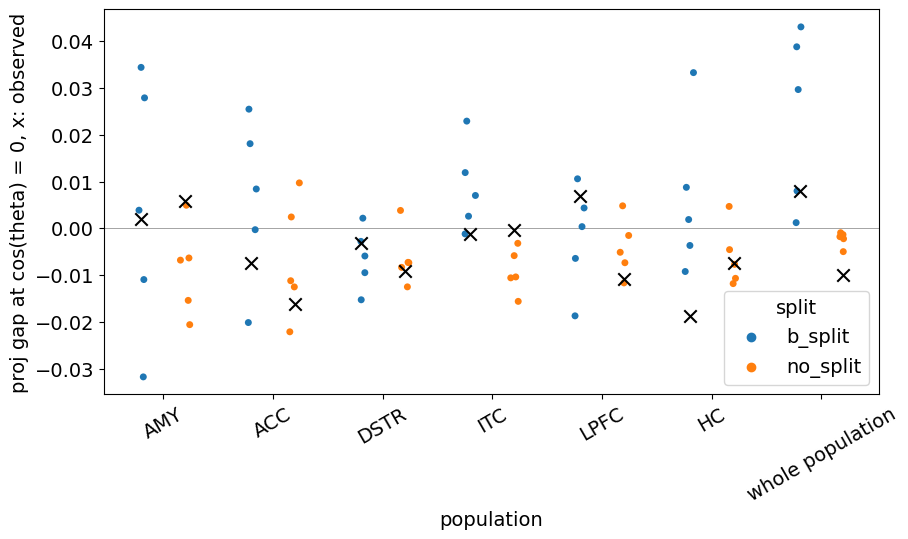

In [8]:
null = summary[summary.cos_theta == 0]
fig, ax = plt.subplots(figsize=(10, 5))
sns.stripplot(null.assign(population=null.population.map(NAMES)), x="population", y="proj_gap", hue="split", dodge=True, ax=ax)
for i, population in enumerate(POPULATIONS):
    for j, split in enumerate(["b_split", "no_split"]):
        ax.scatter(i - 0.2 + 0.4 * j, targets.loc[population, f"proj_gap_peak_{split}"], marker="x", color="black", s=80, zorder=3)
ax.axhline(0, color="grey", linewidth=0.5)
ax.set_ylabel("proj gap at cos(theta) = 0, x: observed")
ax.tick_params(axis="x", rotation=30)
null.groupby(["population", "split"]).proj_gap.agg(["mean", "std"]).round(3)

### The cosine analysis on the same draws

`cos_raw` and `cos_unb` over the full population, against `cos_true`, the cosine of the true vectors
over the same units. v_pref is zero off the pref units, so `cos_true` is cos(theta) shrunk by the
share of u on them. Under no_split, `cos_raw` carries the shared-B bias of Issue 1. `cos_unb` should
track `cos_true` in both, and its spread over repeats shows whether it has more power than the
projection at these SNRs.

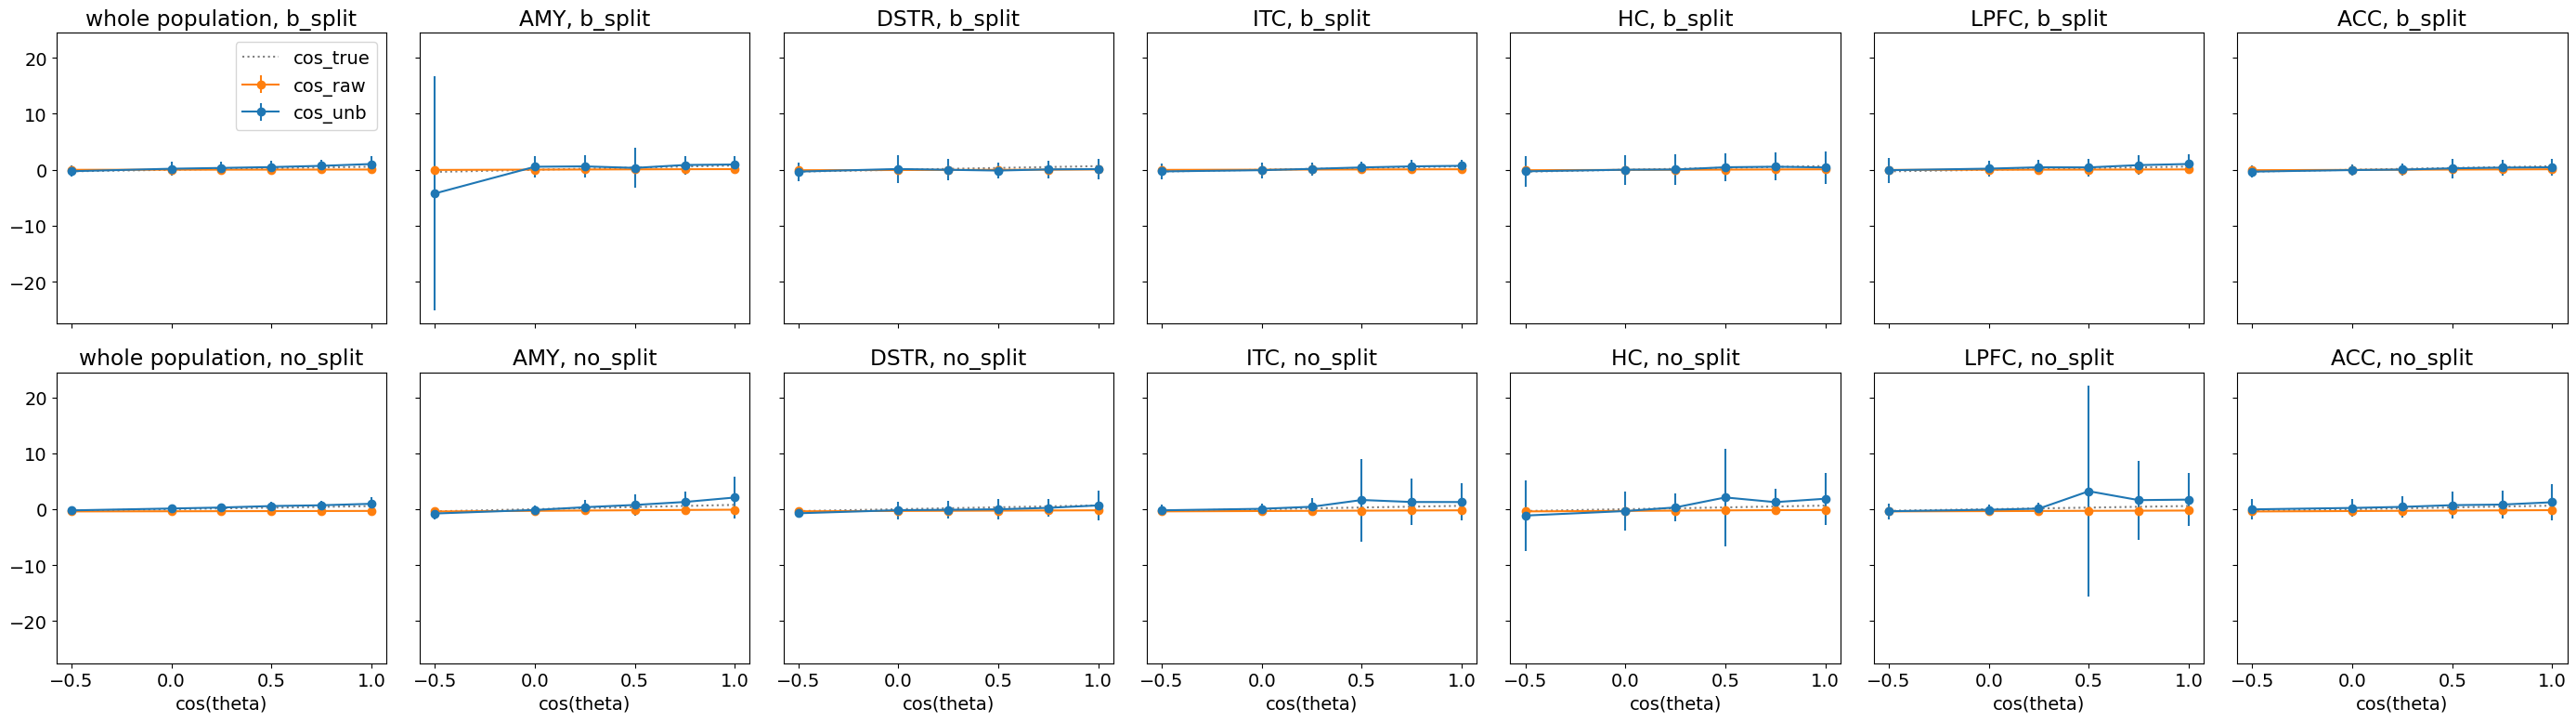

In [9]:
fig, axs = plt.subplots(2, len(POPULATIONS), figsize=(4 * len(POPULATIONS), 8), sharex=True, sharey=True)
for col, population in enumerate(POPULATIONS):
    for row, split in enumerate(["b_split", "no_split"]):
        ax = axs[row, col]
        sub = extras[(extras.population == population) & (extras.split == split)]
        for metric, color in [("cos_raw", "tab:orange"), ("cos_unb", "tab:blue")]:
            stats = sub.groupby("cos_theta")[metric].agg(["mean", "std"]).dropna(subset=["mean"])
            # cos_unb is NaN where the noise correction exceeds a squared norm, att_* at 0
            if stats.empty:
                continue
            ax.errorbar(stats.index, stats["mean"], yerr=stats["std"].fillna(0), marker="o", color=color, label=metric)
        true = sub.groupby("cos_theta").cos_true.mean()
        ax.plot(true.index, true, color="grey", linestyle="dotted", label="cos_true")
        ax.set_title(f"{NAMES[population]}, {split}")
axs[0, 0].legend()
for ax in axs[-1]:
    ax.set_xlabel("cos(theta)")
fig.tight_layout()

### How good is the estimated axis

`rho`: cosine between the estimated stim axis and the true one, over all units and over the pref
units, against the mean-difference formula and the calibration's expectation.

In [10]:
axis_quality = extras.groupby(["population", "split"])[["n_units", "n_pref_units", "rho", "rho_pref", "rho_formula"]].mean()
axis_quality.join(pd.DataFrame(json.load(open(CALIBRATION_PATH))).T[["rho_expected"]], on="population") \
    .rename(index=NAMES, level="population").round(3)

n_units  n_pref_units    rho  rho_pref  \
population       split                                              
AMY              b_split    37.083        11.750  0.319     0.341   
                 no_split   37.083        11.750  0.518     0.574   
ACC              b_split    34.417        10.667  0.391     0.402   
                 no_split   34.417        10.667  0.541     0.531   
DSTR             b_split    35.000         9.833  0.389     0.331   
                 no_split   35.000         9.833  0.487     0.447   
ITC              b_split    87.083        26.583  0.321     0.302   
                 no_split   87.083        26.583  0.500     0.482   
LPFC             b_split   105.583        31.167  0.289     0.283   
                 no_split  105.583        31.167  0.425     0.415   
HC               b_split    41.750        12.167  0.369     0.373   
                 no_split   41.750        12.167  0.520     0.515   
whole population b_split   528.083       160.333  0.213     0.223   
                 no_split  528.083       160.333  0.304     0.307   

                           rho_formula  rho_expected  
population       split                                
AMY              b_split         0.373         0.370  
                 no_split        0.496         0.370  
ACC              b_split         0.422         0.412  
                 no_split        0.549         0.412  
DSTR             b_split         0.375         0.365  
                 no_split        0.497         0.365  
ITC              b_split         0.388         0.383  
                 no_split        0.512         0.383  
LPFC             b_split         0.331         0.324  
                 no_split        0.445         0.324  
HC               b_split         0.397         0.384  
                 no_split        0.522         0.384  
whole population b_split         0.231         0.230  
                 no_split        0.320         0.230